# Repaso final: Turismo internacional

Este repaso usa un contexto distinto al examen, pero practica los mismos patrones: recorrer datos, crear una función, filtrar, agrupar, ordenar, graficar e interpretar.

Trabaje con `turismo_internacional_repaso.csv` sin modificarlo. **Antes de iniciar, guarde una copia como `Apellido_Nombre_Repaso_Final.ipynb`.**

Distribución inequívoca: Parte 1, Parte 2, Parte 3, Parte 4, Parte 5 y cierre.


## Parte 1 — Preparación

**TODO 1.1 — Entrada, proceso y salida**

Escriba aquí una frase que identifique: (1) la entrada —el archivo y sus datos—, (2) el proceso —las operaciones de análisis— y (3) la salida —tablas, gráficos e interpretaciones.


In [112]:
import pandas as pd
import matplotlib.pyplot as plt

archivo = 'turismo_internacional_repaso.csv'
df = pd.read_csv(archivo)
df.head()


print()
print("tipos de datos")
print(df.info())
print(df.isna().sum())

filtro = df.isna().any(axis=1)

filas_nulas = df[df['llegadas_miles'].isna()]
display(filas_nulas)
df.dropna(inplace=True) # este hace que se eliminen las filas con valores nulos en el DataFrame original
df = df.dropna() # es igual que implace true, pero devuelve un nuevo df
df.head()




tipos de datos
<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pais            130 non-null    str    
 1   anio            130 non-null    int64  
 2   llegadas_miles  117 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 KB
None
pais               0
anio               0
llegadas_miles    13
dtype: int64


,pais,anio,llegadas_miles
52,Guatemala,2012,NaN
53,Guatemala,2013,NaN
54,Guatemala,2014,NaN
55,Guatemala,2015,NaN
56,Guatemala,2016,NaN
57,Guatemala,2017,NaN
58,Guatemala,2018,NaN
59,Guatemala,2019,NaN
60,Guatemala,2020,NaN
61,Guatemala,2021,NaN


,pais,anio,llegadas_miles
0,Belice,2012,294.495
1,Belice,2013,294.209
2,Belice,2014,320.564
3,Belice,2015,341.125
4,Belice,2016,386.698


**TODO 1.2 — Construir la cantidad de visitantes**

A partir de `llegadas_miles`, cree la columna `visitantes` en personas. Redondee el resultado y use el tipo entero anulable `Int64`, para conservar como dato faltante los años que no tengan una cifra publicada.


In [113]:
# TODO: cree df["visitantes"] desde df["llegadas_miles"].
# Debe multiplicar por 1 000, redondear y convertir a enteros anulables (Int64).
# No reemplace los valores faltantes por cero.

df['visitantes'] = (df['llegadas_miles'] * 1000).round().astype('Int64')
display(df)

,pais,anio,llegadas_miles,visitantes
0,Belice,2012,294.495,294495
1,Belice,2013,294.209,294209
2,Belice,2014,320.564,320564
3,Belice,2015,341.125,341125
4,Belice,2016,386.698,386698
...,...,...,...,...
125,Perú,2020,897.905,897905
126,Perú,2021,444.331,444331
127,Perú,2022,2009.275,2009275
128,Perú,2023,2524.658,2524658


**TODO 1.3 — Exploración, nulos y limpieza**

Antes de analizar, explore la estructura del DataFrame y la calidad de los datos.

1. Muestre `shape`, `dtypes`, `info()` y la cantidad de nulos por columna.
2. Identifique las filas con `llegadas_miles` faltante y explique qué representan según la documentación de fuentes.
3. Cree `df_limpio` sin valores faltantes en `llegadas_miles`. No convierta los nulos en cero y conserve `df` sin modificar para poder comparar ambos conjuntos.


In [114]:
# TODO: explore df con shape, dtypes, info() e isna().sumprint
print("dimenciones:", df.shape)
# TODO: muestre las filas con llegadas_miles faltante y explique su significado.
print('tipo de datos :\n', df.dtypes)
display(df.info())
# TODO: cree df_limpio excluyendo únicamente los nulos de llegadas_miles.
# No reemplace valores faltantes por cero.


dimenciones: (117, 4)
tipo de datos :
 pais                  str
anio                int64
llegadas_miles    float64
visitantes          Int64
dtype: object
<class 'pandas.DataFrame'>
Index: 117 entries, 0 to 129
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pais            117 non-null    str    
 1   anio            117 non-null    int64  
 2   llegadas_miles  117 non-null    float64
 3   visitantes      117 non-null    Int64  
dtypes: Int64(1), float64(1), int64(1), str(1)
memory usage: 4.7 KB


None

## Parte 2 — Python base: registros y función

1. Muestre `shape`, `dtypes` y una descripción breve de cada columna.
2. Convierta el DataFrame en una lista de diccionarios llamada `registros`.
3. Con un ciclo y una condición, cuente los registros cuya cantidad de llegadas es mayor a 3 000 miles.
4. Complete `resumen_pais`. Debe devolver un diccionario con país, cantidad de años, total y promedio de llegadas para el país solicitado. Si no existe, debe devolver `None`.


In [115]:
# Escriba su solución aquí.
registros  = df.to_dict(orient='records')  # o se puede usar ' series ' #Convertir DataFrame a lista de diccionarios
print ("registros:", registros[:5])  # Mostrar los primeros 5 registros para verificar
# registros = ...
# contador = ...
contador = 0 #por encima de 30000

for registro in registros:
    if registro['llegadas_miles'] >= 30000: 
        contador += 1
print("Cantidad de registros con llegadas_miles >= 30000:", contador)












def resumen_pais(registros, pais):
    total_visitantes = 0
    
    for registro in registros:
        if registro['pais'] == pais:
            #total_visitantes += registro['visitantes']
            valores = registro.get('visitantes') or 0
            total_visitantes += valores
    return total_visitantes




print("\n",
    "total de visitantes para 'Costa Rica':",
    "\n","-----------",
    resumen_pais(registros,
    'Costa Rica'),
    "-----------",
    "\n")



print("total de visitantes para 'Angola':","\n" ,"-----------",resumen_pais(registros, 'Angola'),"-------------","\n")
# Pruebe la función con 'Costa Rica' y con un país inexistente.


registros: [{'pais': 'Belice', 'anio': 2012, 'llegadas_miles': 294.495, 'visitantes': 294495}, {'pais': 'Belice', 'anio': 2013, 'llegadas_miles': 294.209, 'visitantes': 294209}, {'pais': 'Belice', 'anio': 2014, 'llegadas_miles': 320.564, 'visitantes': 320564}, {'pais': 'Belice', 'anio': 2015, 'llegadas_miles': 341.125, 'visitantes': 341125}, {'pais': 'Belice', 'anio': 2016, 'llegadas_miles': 386.698, 'visitantes': 386698}]
Cantidad de registros con llegadas_miles >= 30000: 9

 total de visitantes para 'Costa Rica': 
 ----------- 31844233 ----------- 

total de visitantes para 'Angola': 
 ----------- 0 ------------- 



## Parte 3 — Pandas: Análisis Comparativo y de Impacto

Con el nuevo conjunto de datos, podemos realizar un análisis regional más profundo.

1.  **Ranking de Líderes Regionales:**
    *   Calcula el **total de llegadas por país** para todo el período (2012-2024).
    *   Genera un ranking ordenado de mayor a menor para identificar los 3 países con más llegadas en la región.

2.  **Análisis de Impacto (COVID-19):**
    *   Crea un nuevo DataFrame que contenga únicamente los datos de 2019 y 2020.
    *   A partir de él, calcula la **caída porcentual** en el turismo para cada país. La fórmula es `((llegadas_2019 - llegadas_2020) / llegadas_2019) * 100`.
    *   Muestra una tabla con los resultados, ordenada de mayor a menor caída porcentual, para ver qué países fueron los más afectados.


In [116]:
# Escriba sus filtros, cálculos, tabla resumen y ranking aquí.
top_3 = df.groupby('pais')['visitantes'].sum().sort_values(ascending=False).reset_index()
print("rankings de visitantes por pais top 3")
display(top_3.head(3))





# Para el ranking, agrupe las llegadas_miles por país, ordene de mayor a menor
# y conserve los tres primeros resultados.





rankings de visitantes por pais top 3


,pais,visitantes
0,México,451162715
1,Colombia,39727076
2,Perú,38380784


In [117]:
#calculemos la caida porcentual de llegadas_miles entre 2019 y 2020 para cada país.
df['caida_porcentual'] = df.groupby('pais')['llegadas_miles'].pct_change() * 100    
# aqui agrupamos por país y calculamos el cambio porcentual de llegadas_miles entre años consecutivos.



df_2019 = df[df['anio'] == 2019].set_index('pais')['llegadas_miles']
#definimos df_2019 con el año 2019 y lo ponemos como indice el pais y nos quedamos con la columna llegadas_miles


df_2020 = df[df['anio'] == 2020].set_index('pais')['llegadas_miles']
#definimos df_2020 con el año 2020 y lo ponemos como indice el pais y nos quedamos con la columna llegadas_miles



caida_porcentual = (((df_2019 - df_2020) / df_2019) * 100).sort_values(ascending=False)
#calculamos la caida porcentual entre 2019 y 2020 y ordenamos de menor a mayor


df_rersumen = caida_porcentual.reset_index(name='caida_porcentual')
#hacemos el resumen y lo convertimos en un DataFrame con reset_index y le damos nombre a la columna de caida porcentual



## Parte 4 — Visualización Comparativa e Interpretación

Ahora, vamos a contar la historia de los datos con visualizaciones más ricas.

1.  **Gráfico de Líneas Comparativo:**
    *   Construye una gráfica de líneas que compare la evolución de llegadas para **todos los países** a lo largo de los años.
    *   **Interpretación:** Tu análisis debe mencionar: (1) La escala de México en comparación con los demás, (2) la tendencia general antes de 2020, y (3) el impacto visible de la pandemia en 2020 en todo el grupo.

2.  **Gráfico de Barras del Impacto (COVID-19):**
    *   Crea un **gráfico de barras horizontales** que muestre la **caída porcentual** por país que calculaste en la Parte 3.
    *   **Interpretación:** Explica qué países sufrieron el mayor y menor impacto relativo según la gráfica.

3.  **Gráfico de Barras de Recuperación:**
    *   Crea un **gráfico de barras agrupadas** que compare las llegadas de **2019 (pre-pandemia)** con las de **2022 (recuperación)** para cada país.
    *   **Interpretación:** Describe qué países parecen haberse recuperado más rápido y si alguno ha superado sus niveles pre-pandemia.


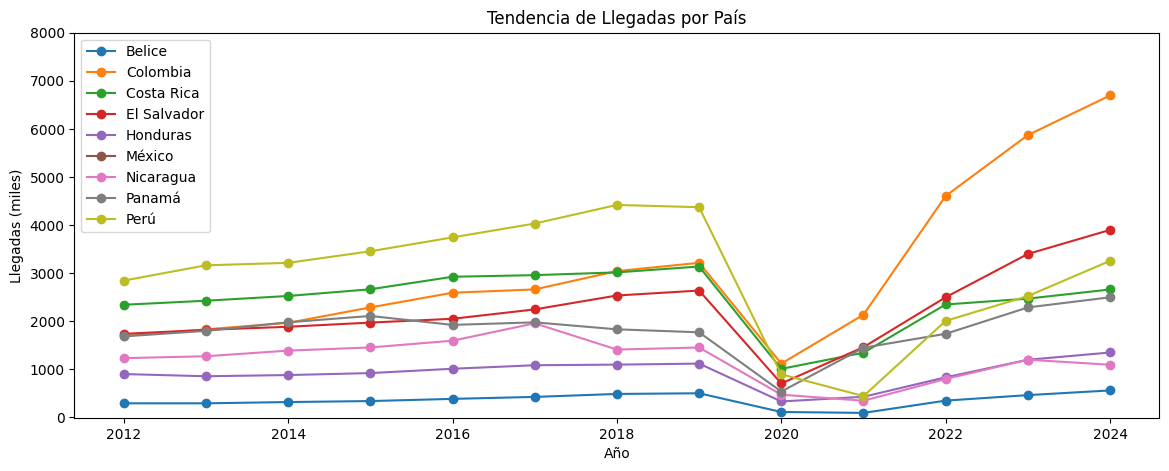

In [118]:
# Escriba aquí las tres gráficas
plt.figure(figsize=(14,5))
for pais,datos in df.groupby('pais'):
    plt.plot(datos['anio'], datos['llegadas_miles'], marker= 'o', label=pais)
plt.xlabel('Año')
plt.ylabel('Llegadas (miles)')
plt.title('Tendencia de Llegadas por País')
plt.legend()



minimos = df['llegadas_miles'].min()- 100
maximos =  8000
plt.ylim(minimos, maximos)
plt.show()





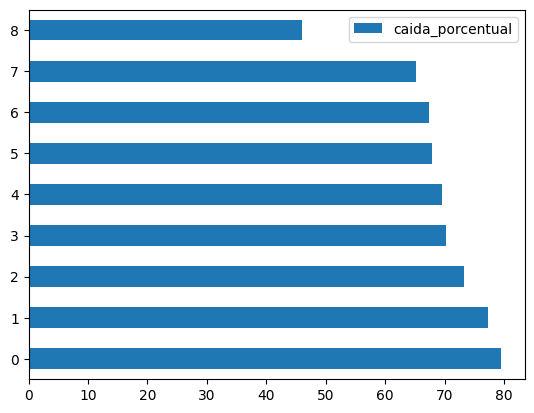

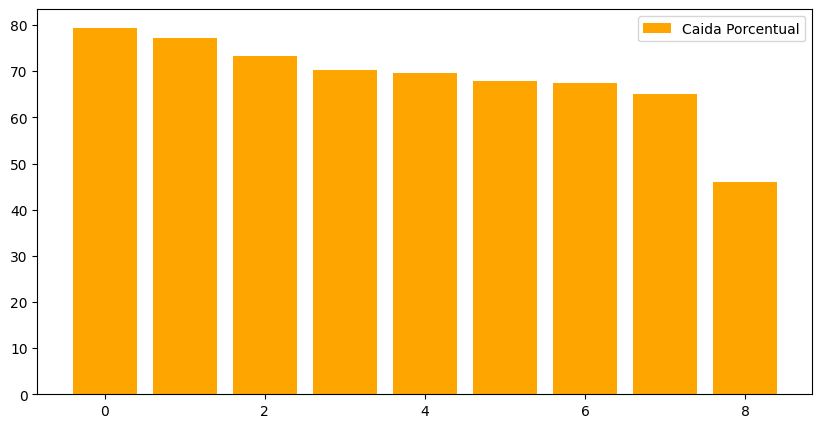

,pais,caida_porcentual
0,Perú,79.461374
1,Belice,77.274796
2,El Salvador,73.209549
3,Honduras,70.267857
4,Panamá,69.565217
5,Costa Rica,67.792491
6,Nicaragua,67.422680
7,Colombia,65.159172
8,México,46.062741


In [119]:
df_rersumen.plot(kind='barh')



plt.figure(figsize=(10,5))
plt.bar(df_rersumen.index, df_rersumen['caida_porcentual'],label='Caida Porcentual', color='orange')
plt.legend()
plt.show()  
display(df_rersumen)

## Parte 5 — Mini-simulacro individual

Sin consultar soluciones, resuelva lo siguiente:

1. Defina la lista de países de Centroamérica: Belice, Costa Rica, El Salvador, Guatemala, Honduras, Nicaragua y Panamá. Convierta el DataFrame a una lista de diccionarios y cree una función que recorra los registros, use una condición y devuelva el total de llegadas de un país indicado; devuelva `None` si no existe.
2. Use un filtro compuesto con `isin(...)` para conservar únicamente Centroamérica y registros de 2019 o posteriores. Excluya los valores faltantes antes del análisis y guarde el resultado como `df_centroamerica`.
3. Con `df_centroamerica`, cree un resumen con `groupby(...).agg(...)` y seleccione con `nlargest(5, 'visitantes')` las cinco observaciones de mayor valor.
4. Elabore una gráfica de barras horizontales del ranking regional en visitantes y redacte un hallazgo numérico verificable, una interpretación y una limitación del análisis de Centroamérica.

**Autoevaluación:** ¿su respuesta incluye lista de diccionarios, ciclo, condición y función?, ¿sus filtros usan la columna correcta?, ¿aplicó `groupby(...).agg(...)` y `nlargest(5, ...)`?, ¿sus gráficos son legibles?, ¿sus afirmaciones tienen evidencia y una limitación?


In [120]:
# Resuelva aquí el mini-simulacro.
# Defina la lista regional y cree df_centroamerica con el filtro compuesto y sin valores faltantes.
# Incluya la función, groupby(...).agg(...), nlargest(5, 'visitantes')
# y su interpretación de Centroamérica en visitantes, con evidencia y limitación.


## Cierre y autoevaluación

Compare su trabajo con la lista de autoevaluación de la Parte 5. Entregue el notebook con su nombre, código ejecutado, tres gráficos, interpretaciones con evidencia y una limitación. La retroalimentación docente se realiza después del intento individual.
